# Linearizing for Fun and Profit: Linear Regression on Curvy Data

In Unit 2 you built a model that fits

$$\tilde{y} = a \cdot x + b$$

Here's the key idea for today. **"Linear" means linear in the parameters $a$
and $b$, not linear in $x$.** Your fitting code never checks what $x$ *is*.
If you hand it $z = x^2$, or $z = \ln x$, or $z = \sqrt{x}$, it will happily
find the best $a$ and $b$ for $\hat{y} = a \cdot z + b$.

Choosing $z$ is **your** job. That's called **feature engineering**, and you'll
see a lot more of it this year.

In [1]:
import numpy as np
import sklearn
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## Tools

`diagnose` nicely plots your data, finds a best-fit line and produces a residual plot

In [2]:
def diagnose(z, y, z_label="z", y_label="y", title=""):
    """Fit y = a*z + b, then plot the fit and the residuals side by side.
    Returns (a, b)."""
    z, y = np.asarray(z, float), np.asarray(y, float)
    a, b = np.polyfit(z, y, 1)
    y_hat = a * z + b
    resid = y - y_hat

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    order = np.argsort(z)
    ax1.scatter(z, y, s=25)
    ax1.plot(z[order], y_hat[order], "r-", lw=2)
    ax1.set_xlabel(z_label); ax1.set_ylabel(y_label)
    ax1.set_title(f"{title}  (R² = {sklearn.metrics.r2_score(y, y_hat):.4f})")

    ax2.scatter(z, resid, s=25)
    ax2.axhline(0, color="gray", lw=1)
    ax2.set_xlabel(z_label); ax2.set_ylabel("residual")
    ax2.set_title("Residuals: want NO pattern")
    plt.tight_layout(); plt.show()

    print(f"a = {a:.5g},  b = {b:.5g}")
    return a, b

## Part 1: A line that's "right" but wrong

Braking distance (meters) vs. speed (km/h) for a car on dry pavement.

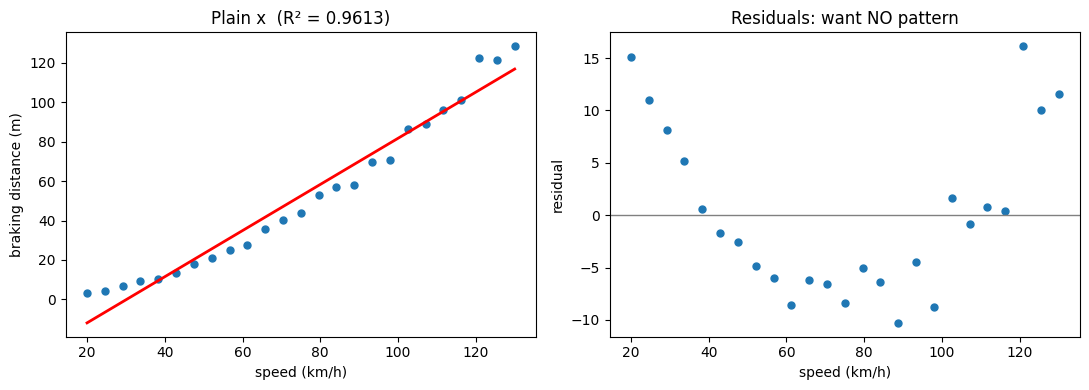

a = 1.1704,  b = -35.327


In [5]:
speed = np.array([20.        , 24.58333333, 29.16666667, 33.75      ,
       38.33333333, 42.91666667, 47.5       , 52.08333333,
       56.66666667, 61.25      , 65.83333333, 70.41666667,
       75.        , 79.58333333, 84.16666666, 88.75      ,
       93.33333333, 97.91666667, 102.5       , 107.08333333,
       111.66666667, 116.25      , 120.83333333, 125.41666667,
       130.        ])
brake_dist = np.array([  3.17704304,   4.41971416,   6.93419005,   9.38608491,
        10.11993977,  13.24389985,  17.73373988,  20.75737431,
        25.02141789,  27.76447162,  35.58912156,  40.48128355,
        44.04882581,  52.74258869,  56.80536208,  58.26963677,
        69.44998986,  70.48131797,  86.26802425,  89.1734277 ,
        96.18286537, 101.10309327, 122.23919445, 121.55131146,
       128.43226959])

a,b = diagnose(speed, brake_dist, "speed (km/h)", "braking distance (m)", "Plain x")

The fit converged and $R^2$ looks fine. **Now look at the residuals.**
That smile shape means the model is systematically too high in the middle
and too low at the ends. The algorithm did its job. The *feature* is wrong.

**Question:** Physics says kinetic energy $\propto v^2$. What should $z$ be?

**Hypothesis**: The relationship between brake_dist and speed *squared* is nearly linear.

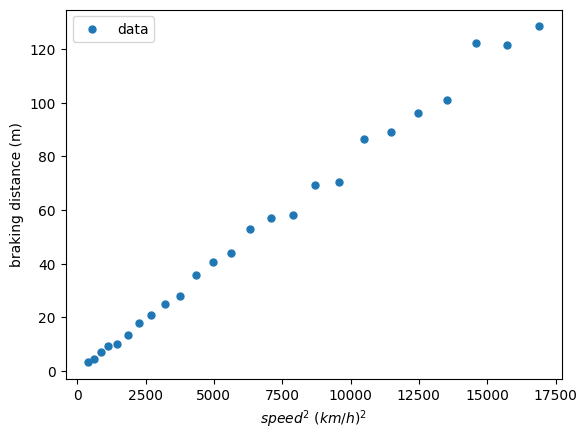

In [14]:
xs = np.linspace(0, 140, 200)
plt.scatter(speed**2, brake_dist, s=25, label="data")
plt.xlabel("$speed^2$ $(km/h)^2$"); plt.ylabel("braking distance (m)")
plt.legend(); plt.show()

Use the `diagnose` function to compared $x^2$ against $y$ and make a linear regression on the transformed variables.

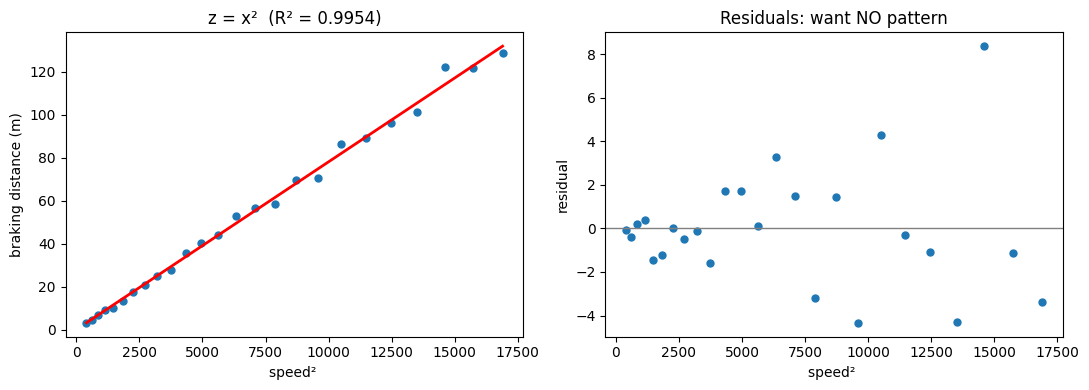

a = 0.0077911,  b = 0.11954


In [17]:
a, b = diagnose(speed**2, brake_dist, "speed² ", "braking distance (m)", "z = x²")

Straight line, patternless residuals. Now map it back to the original axes.
We fit a *line* in $z$, but it's a *parabola* in $x$:

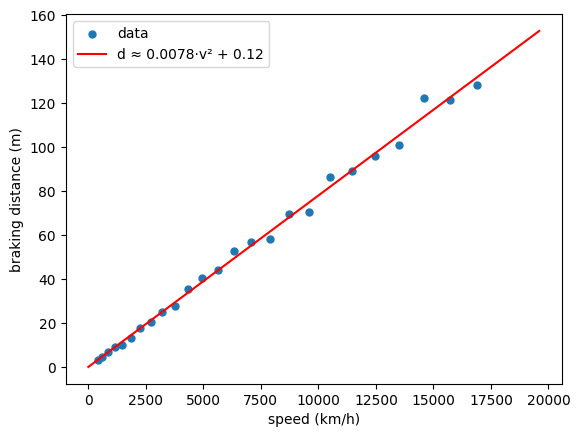

In [19]:
xs = np.linspace(0, 140, 200)
plt.scatter(speed**2, brake_dist, s=25, label="data")
plt.plot(xs**2, a * xs**2 + b, "r-", label=f"d ≈ {a:.4f}·v² + {b:.2f}")
plt.xlabel("speed (km/h)"); plt.ylabel("braking distance (m)")
plt.legend(); plt.show()

## Part 2: Transforming y

Some curves can't be fixed by changing $x$ alone. For an exponential,

$$y = a e^{kx} \quad\Longrightarrow\quad \ln y = \ln a + kx$$

so we plot $\ln y$ vs. $x$. The slope is $k$ and the intercept is $\ln a$.

For a power law,

$$y = a x^p \quad\Longrightarrow\quad \ln y = \ln a + p \ln x$$

so we plot $\ln y$ vs. $\ln x$ (a "log-log" plot). **The slope is the exponent.**

---

# Activity: Linearize

For **each** dataset below:
1. Plot the raw data.
2. Find a transform of $x$ and/or $y$ that makes the scatter straight **and**
   the residuals patternless. Use `diagnose(...)`.
3. Write the final model in the **original** variables (e.g. $T = 2.01\sqrt{L}$).
4. Answer the dataset's question.

### Dataset A: Pendulum lab
Period (seconds) vs. string length (meters), measured with a stopwatch.

**Question:** Use your model to estimate $g$. (Theory: $T = 2\pi\sqrt{L/g}$.)

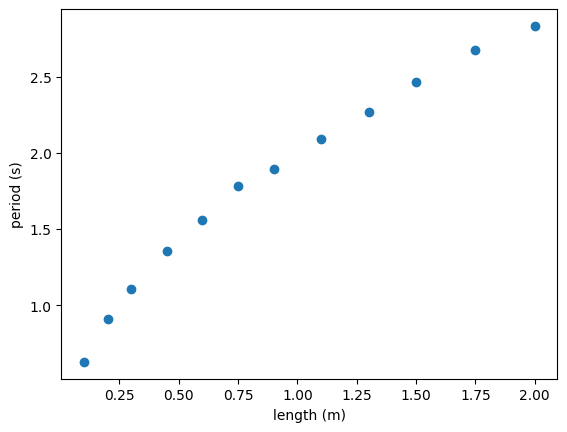

In [20]:
length = np.array([0.10, 0.20, 0.30, 0.45, 0.60, 0.75, 0.90, 1.10, 1.30, 1.50, 1.75, 2.00])
period = np.array([0.62733131, 0.90778648, 1.10607685, 1.35396509, 1.56250899,
       1.78013766, 1.89499365, 2.09373563, 2.27099248, 2.46923947,
       2.67635622, 2.83472776])

plt.scatter(length, period); plt.xlabel("length (m)"); plt.ylabel("period (s)"); plt.show()

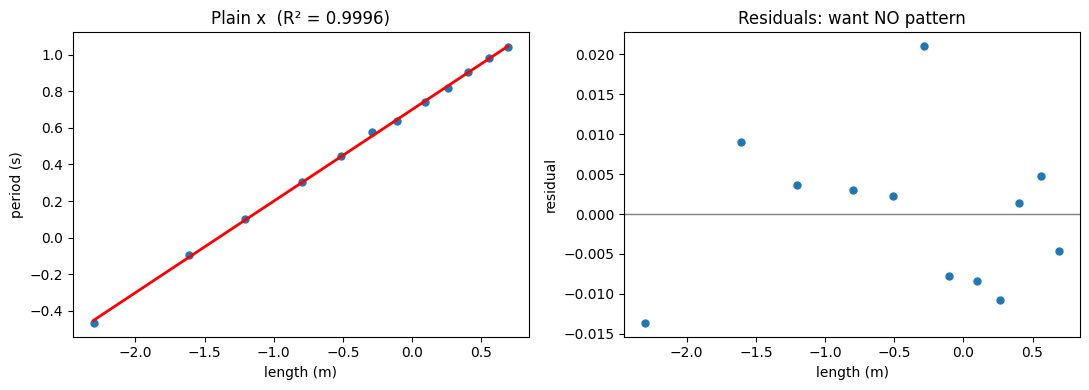

a = 0.50045,  b = 0.69966


(np.float64(0.5004453679734635), np.float64(0.6996568236695042))

In [21]:
# TODO: your transform + diagnose(...) here
diagnose(np.log(length), np.log(period), "length (m)", "period (s)", "Plain x")

### Dataset B: Moore's law
Approximate transistor counts for notable Intel processors.

**Question:** According to your model, how many years does it take the
transistor count to double?

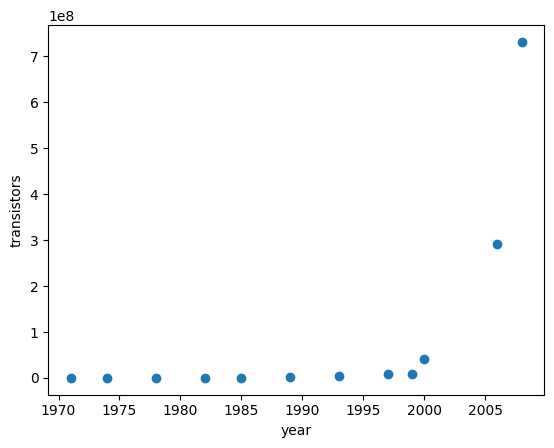

In [ ]:
year = np.array([1971, 1974, 1978, 1982, 1985, 1989, 1993, 1997, 1999, 2000, 2006, 2008])
transistors = np.array([2.3e3, 4.5e3, 2.9e4, 1.34e5, 2.75e5, 1.18e6, 3.1e6,
                        7.5e6, 9.5e6, 4.2e7, 2.91e8, 7.31e8])

plt.scatter(year, transistors); plt.xlabel("year"); plt.ylabel("transistors"); plt.show()

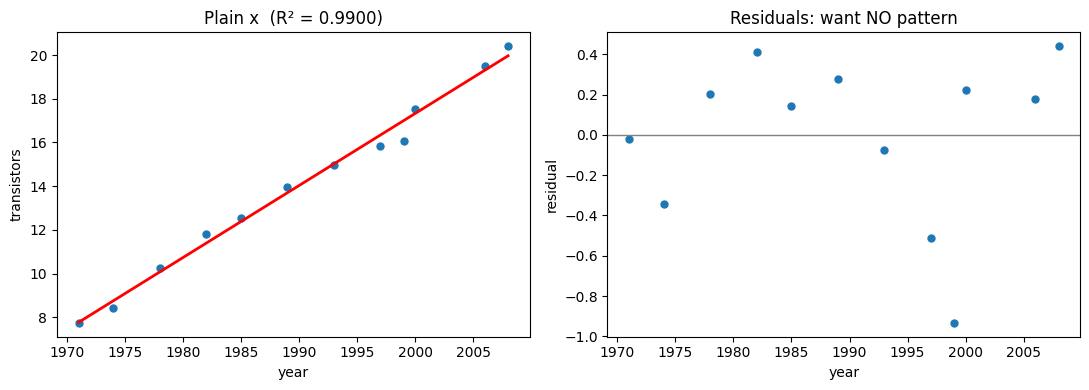

a = 0.32989,  b = -642.45


(np.float64(0.32988811663376416), np.float64(-642.4461033487717))

In [ ]:
diagnose(year, np.log(transistors), "year", "transistors", "Plain x")

### Dataset C: The planets
Semi-major axis $a$ (AU) and orbital period $T$ (years).

**Question:** Find $p$ in $T = c \cdot a^p$. Congratulations: you've just
rediscovered something Johannes Kepler spent about a decade on.

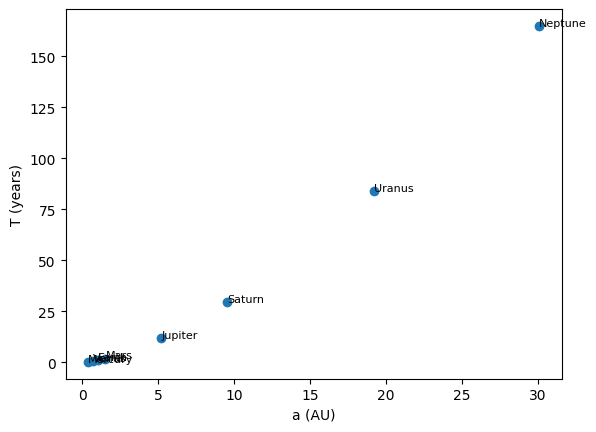

In [ ]:
planets = ["Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", "Uranus", "Neptune"]
a_AU = np.array([0.387, 0.723, 1.000, 1.524, 5.203, 9.537, 19.19, 30.07])
T_yr = np.array([0.241, 0.615, 1.000, 1.881, 11.86, 29.46, 84.01, 164.8])

plt.scatter(a_AU, T_yr)
for name, a, t in zip(planets, a_AU, T_yr):
    plt.annotate(name, (a, t), fontsize=8)
plt.xlabel("a (AU)"); plt.ylabel("T (years)"); plt.show()

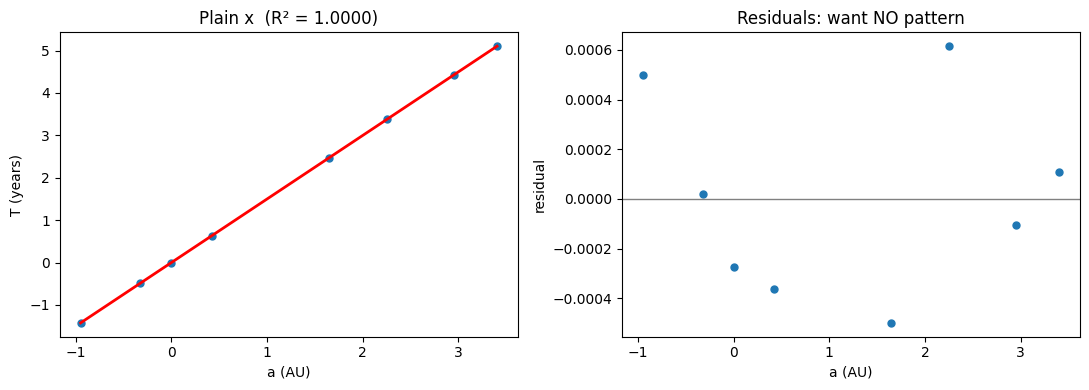

a = 1.4997,  b = 0.00027618


(np.float64(1.4997221898541804), np.float64(0.00027617939333727317))

In [ ]:
diagnose(np.log(a_AU), np.log(T_yr), "a (AU)", "T (years)", "Plain x")

### Dataset D (Challenge): Cooling coffee
A mug of coffee cools in a room that is 21 °C.

**Question:** Newton's law of cooling says the coffee approaches room
temperature exponentially. Taking $\ln T$ *almost* works. Check the
residuals. What do you need to do first? Then predict when the coffee
reaches 40 °C.

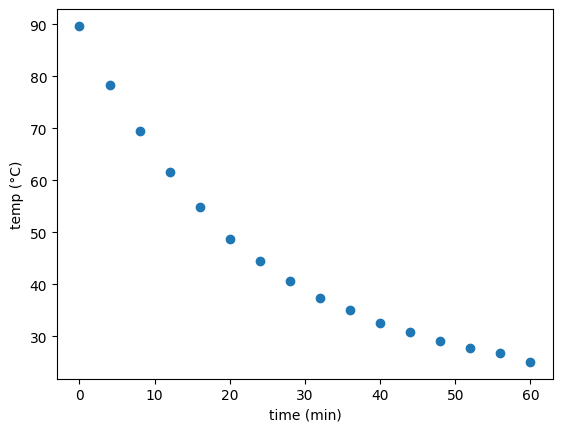

In [ ]:
minutes = np.array([ 0,  4,  8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60])
T_room = 21.0
coffee = np.array([89.66393741, 78.3038521 , 69.39990361, 61.50693108, 54.80316737,
       48.78710264, 44.5249558 , 40.61880215, 37.43549079, 35.00358175,
       32.49506151, 30.7983428 , 28.98446498, 27.7622548 , 26.80422816,
       25.05431805])

plt.scatter(minutes, coffee); plt.xlabel("time (min)"); plt.ylabel("temp (°C)"); plt.show()

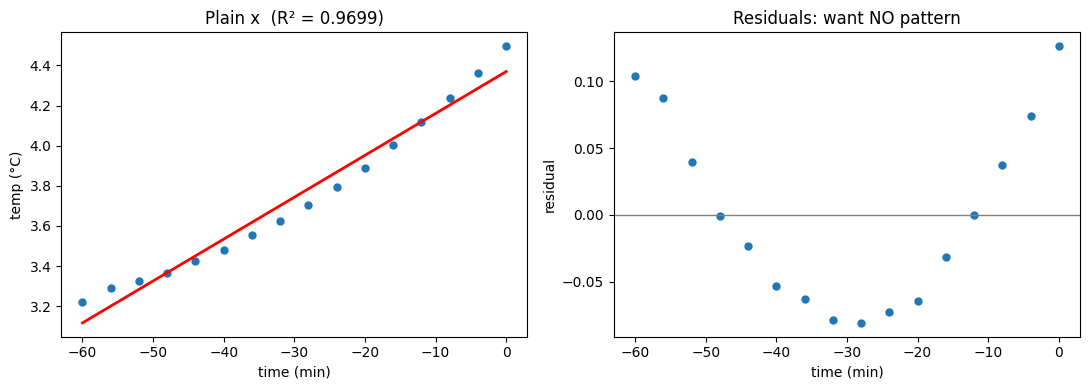

a = 0.020875,  b = 4.3696


(np.float64(0.02087534096664372), np.float64(4.369626320966988))

In [ ]:
diagnose(-minutes, np.log(coffee), "time (min)", "temp (°C)", "Plain x")